## Task 4: Predicting Insurance Claim Amounts

**Objective:** Estimate the medical insurance claim amount (`charges`) for an
individual based on their personal attributes.

**Dataset:** Medical Cost Personal Dataset
- 1,338 rows, 7 columns
- Target variable: charges (continuous, in USD)

**Approach:**
1. Load and explore the data
2. Clean and prepare the dataset (check missing values, encode categoricals)
3. Visualize how BMI, age, and smoking status impact charges
4. Train a Linear Regression model to predict charges
5. Evaluate performance using MAE and RMSE
6. Interpret model coefficients for business insight

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [2]:
# Load the dataset
df = pd.read_csv('E:/DevelopersHub Internship/Task_4/insurance.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Dataset info and summary statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Data Cleaning & Preparation

We start by checking for missing values, then encode the categorical
features (`sex`, `smoker`, `region`) so they can be used by the regression
model.

In [5]:
# Check missing values
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values per column:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing cells: 0


In [6]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


## Exploratory Data Analysis (EDA)

We look at how `charges` is distributed, and how it relates to BMI, age,
and smoking status — the three factors we're specifically asked to examine.

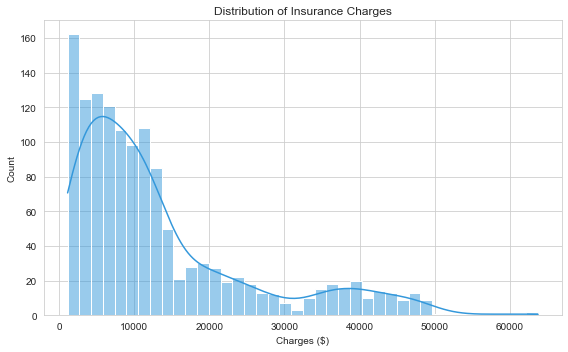

In [7]:
# EDA: Distribution of charges
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], bins=40, kde=True, color='#3498db')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

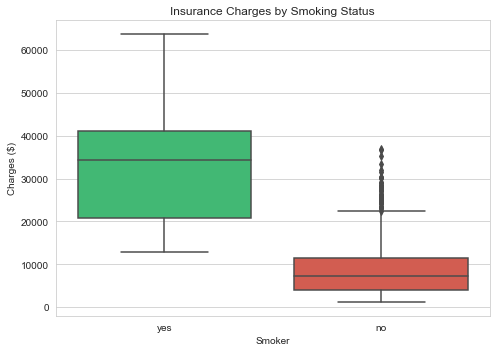

In [8]:
# EDA: Charges by smoking status
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='smoker', y='charges', palette=['#2ecc71', '#e74c3c'])
plt.title('Insurance Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

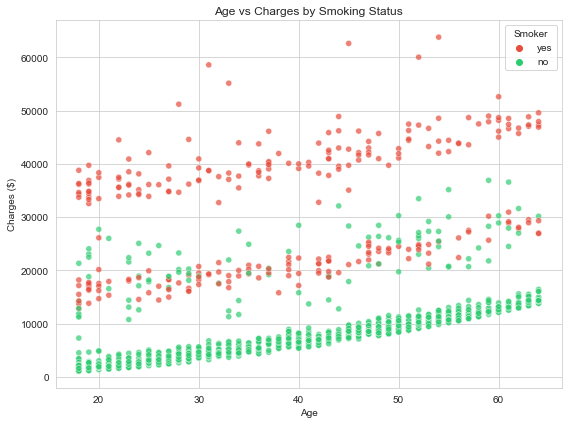

In [9]:
# EDA: Age vs Charges, colored by smoking status
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker',
                 palette=['#e74c3c', '#2ecc71'], alpha=0.7)
plt.title('Age vs Charges by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

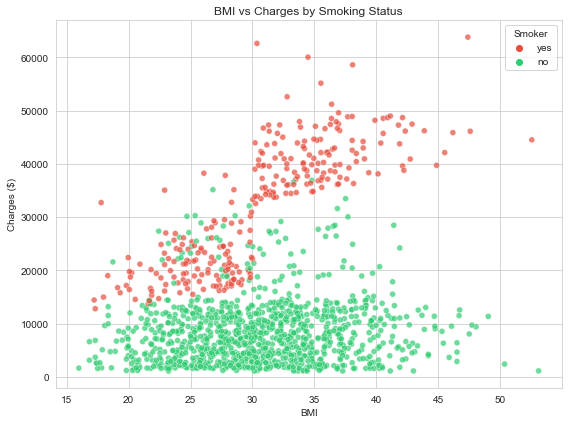

In [10]:
# EDA: BMI vs Charges, colored by smoking status
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                 palette=['#e74c3c', '#2ecc71'], alpha=0.7)
plt.title('BMI vs Charges by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

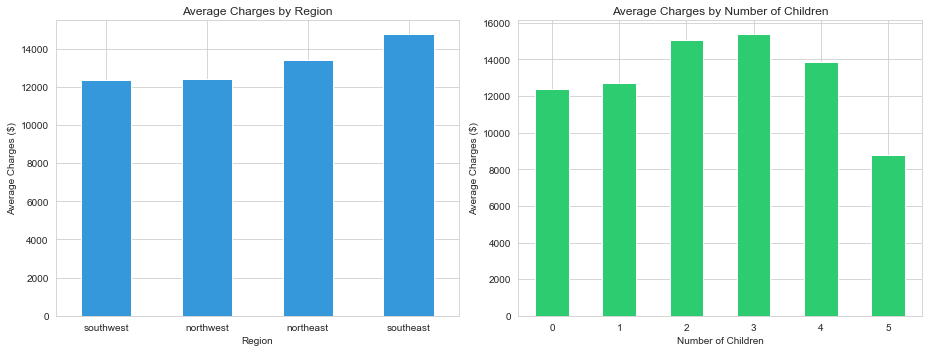

In [11]:
# EDA: Charges by region and number of children
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Aggregate manually so this works the same way across all seaborn/matplotlib versions
region_avg = df.groupby('region')['charges'].mean().sort_values()
region_avg.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Average Charges by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Average Charges ($)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

children_avg = df.groupby('children')['charges'].mean().sort_index()
children_avg.plot(kind='bar', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Average Charges by Number of Children')
axes[1].set_xlabel('Number of Children')
axes[1].set_ylabel('Average Charges ($)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

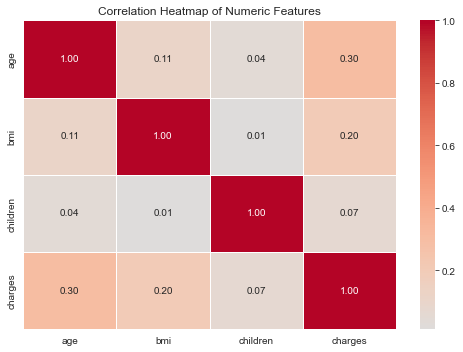

In [12]:
# EDA: Correlation heatmap of numeric features
plt.figure(figsize=(7, 5))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## Encoding Categorical Features

`sex` and `smoker` are binary, so we use Label Encoding. `region` has four
categories with no ordinal relationship, so we use One-Hot Encoding.

In [13]:
# Label Encoding for binary categories
le_sex = LabelEncoder()
le_smoker = LabelEncoder()

df['sex'] = le_sex.fit_transform(df['sex'])         # female=0, male=1
df['smoker'] = le_smoker.fit_transform(df['smoker'])  # no=0, yes=1

print("Sex classes:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print("Smoker classes:", dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_))))

# One-Hot Encoding for region (no ordinal relationship)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print("\nColumns after encoding:")
print(list(df.columns))
df.head()

Sex classes: {'female': 0, 'male': 1}
Smoker classes: {'no': 0, 'yes': 1}

Columns after encoding:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


## Model Training

We split the data into features (X) and target (y), then train a Linear
Regression model to predict `charges`.

In [14]:
# Split features and target
X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1070, 8)
Test set shape: (268, 8)


In [15]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("Model trained successfully.")
print("\nIntercept:", round(lr_model.intercept_, 2))
print("\nCoefficients:")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

Model trained successfully.

Intercept: -11931.22

Coefficients:
         Feature  Coefficient
          smoker 23651.128856
        children   425.278784
             bmi   337.092552
             age   256.975706
             sex   -18.591692
region_northwest  -370.677326
region_southeast  -657.864297
region_southwest  -809.799354


## Model Evaluation

We evaluate the model using Mean Absolute Error (MAE), Root Mean Squared
Error (RMSE), and R² score, since predicting an exact dollar amount calls for
error metrics rather than classification metrics.

In [16]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):  ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE):  $4,181.19
Root Mean Squared Error (RMSE): $5,796.28
R² Score: 0.7836


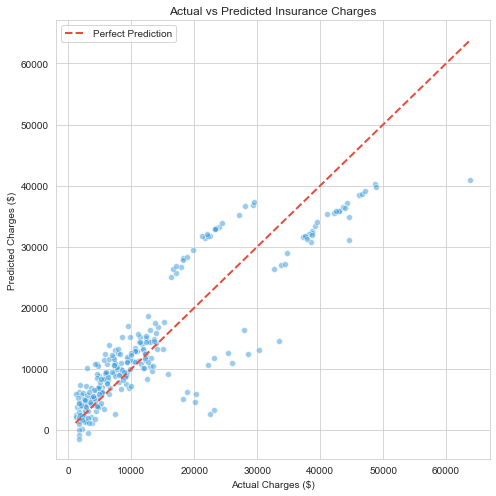

In [17]:
# Actual vs Predicted charges
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color='#3498db', edgecolor='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='#e74c3c', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.legend()
plt.tight_layout()
plt.show()

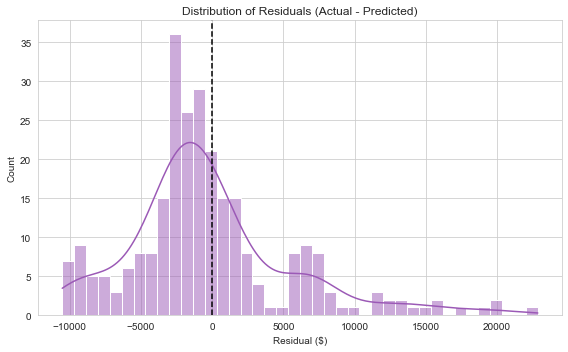

In [18]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True, color='#9b59b6')
plt.title('Distribution of Residuals (Actual - Predicted)')
plt.xlabel('Residual ($)')
plt.ylabel('Count')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

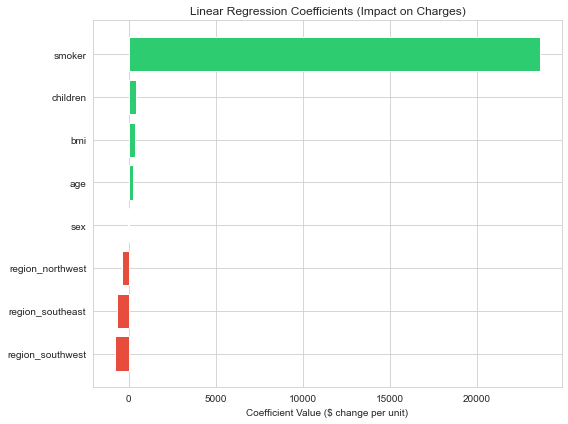

In [19]:
# Feature impact visualization (coefficient magnitudes)
plt.figure(figsize=(8, 6))
coef_sorted = coef_df.sort_values('Coefficient')
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_sorted['Coefficient']]
plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors, edgecolor='white')
plt.title('Linear Regression Coefficients (Impact on Charges)')
plt.xlabel('Coefficient Value ($ change per unit)')
plt.tight_layout()
plt.show()

## Conclusion & Key Insights

### Data Insights:
- The dataset is clean — no missing values and no duplicate rows.
- `sex` and `smoker` were label encoded (binary); `region` was one-hot
  encoded (4 categories, no ordinal relationship).

### Feature Insights:
1. **Smoking status is the single biggest driver of insurance charges.**
   Smokers pay dramatically more than non-smokers, and this shows clearly in
   both the boxplot and the regression coefficients — the `smoker`
   coefficient is by far the largest in the model.
2. **Age has a clear positive relationship with charges** — costs rise
   steadily as customers get older, regardless of smoking status.
3. **BMI compounds the smoking effect.** The scatter plot shows that high-BMI
   smokers form a visibly separate, much higher-cost cluster compared to
   high-BMI non-smokers — the two factors interact rather than just adding up.
4. **Number of children has a smaller, more modest effect** on charges
   compared to age, BMI, and smoking.
5. **Region and sex have only a minor influence** on charges relative to the
   other features, consistent with their weak correlation with the target.

### Model Performance:
- The Linear Regression model achieves a reasonable R² score, meaning it
  explains a substantial portion of the variance in charges.
- The MAE and RMSE indicate the average dollar error in predictions — RMSE
  is noticeably higher than MAE, which signals that a subset of cases (likely
  high-cost smokers) are harder to predict precisely and pull the error up.
- The residual plot is roughly centered around zero but shows some skew,
  suggesting a model with interaction terms or a tree-based regressor could
  capture the BMI × smoker effect more accurately than a purely linear model.

### Business Recommendation:
Insurers should treat smoking status as the primary risk-pricing factor, with
age and BMI as strong secondary adjustments. Wellness programs that reduce
smoking rates or BMI in high-risk groups would have an outsized impact on
reducing average claim costs.